# Computer Vision — Session 1: Images & CNNs
### ITI · Instructor: Ahmed Abdelsalam

You've met neural networks. Now let's point them at **images**. Today's goal is to make two things concrete:
1. **An image is just an array of numbers** — nothing magic.
2. **A CNN is a neural network that slides small filters over an image** to find patterns.

We'll keep it simple and visual — see everything, don't over-theorise.

**Today's map**
1. What is Computer Vision?
2. Images as arrays (pixels, channels, RGB vs gray)
3. Loading & manipulating images (OpenCV + matplotlib)
4. Getting images ready for a model
5. Convolution: sliding a filter
6. Pooling, stride, padding
7. Putting it together: a CNN

> **Setup note:** these notebooks are made for **Google Colab** (free GPU, everything pre-installed). Just run the cells top to bottom.

## Setup — run this first

If anything is missing (e.g. on a fresh machine), uncomment the install line.

In [1]:
# !pip install opencv-python scikit-image torch torchvision matplotlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data
print("Ready.")

Ready.


## 1. What is Computer Vision?

Computer Vision (CV) is teaching computers to **understand images**. Three tasks cover most of it:

| Task | Question it answers | Example |
|------|--------------------|---------|
| **Classification** | *What* is in this image? | "This is a cat." |
| **Detection** | What is here, and *where*? | boxes around each car |
| **Segmentation** | Which *pixels* belong to what? | outline of the road |

Today we focus on the foundations that all three build on: images, filters, and CNNs.

## 2. An image is just an array of numbers

A **grayscale** image is a 2D grid of numbers. Each number is a **pixel**: `0` = black, `255` = white, values in between are shades of gray.

A **color** image adds a third dimension — **3 channels**: Red, Green, Blue. So its shape is `(height, width, 3)`.

shape: (3, 3)
one pixel: 255


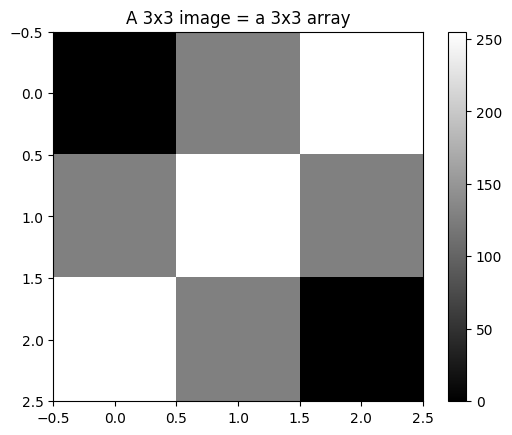

In [4]:
# A tiny 3x3 grayscale image made by hand
tiny = np.array([
    [  0, 128, 255],
    [128, 255, 128],
    [255, 128,   0]
], dtype=np.uint8)

print("shape:", tiny.shape)     # (3, 3) -> height 3, width 3
print("one pixel:", tiny[0, 2]) # top-right = 255 (white)

plt.imshow(tiny, cmap="gray")
plt.title("A 3x3 image = a 3x3 array")
plt.colorbar()
plt.show()

Now a real image. `skimage` gives us a sample so we don't need to download anything.

<class 'numpy.ndarray'>
shape: (512, 512, 3)
dtype: uint8
top-left pixel (R,G,B): [154 147 151]


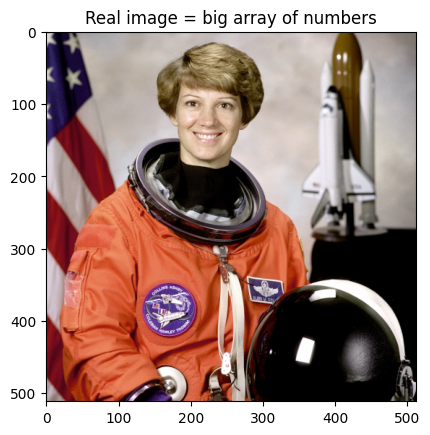

In [7]:
img = data.astronaut()   # a real RGB photo, as a NumPy array
print(type(img))
print("shape:", img.shape)      # (512, 512, 3) -> height, width, 3 channels
print("dtype:", img.dtype)      # uint8 -> values 0..255
print("top-left pixel (R,G,B):", img[0, 0])

plt.imshow(img)
plt.title("Real image = big array of numbers")
#plt.axis("off")
plt.show()

### Splitting the color channels
Each channel is just a grayscale image showing how much of that color is present.

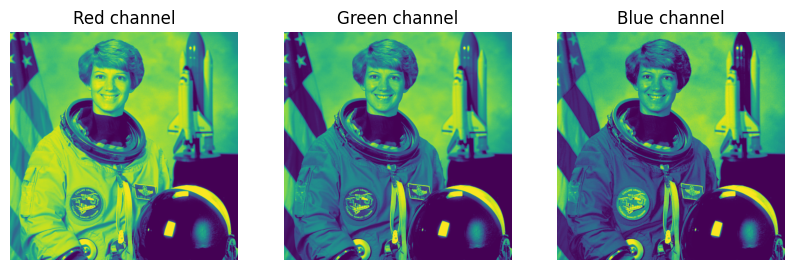

In [11]:
R = img[0:512, 0:512, 0]
G = img[:, :, 1]
B = img[:, :, 2]

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(R); ax[0].set_title("Red channel");   ax[0].axis("off")
ax[1].imshow(G); ax[1].set_title("Green channel"); ax[1].axis("off")
ax[2].imshow(B); ax[2].set_title("Blue channel");  ax[2].axis("off")
plt.show()

🔵 **Your turn:** print the shape of `img`, and print the pixel value at row 100, column 200. Is it brighter in red or blue?

In [12]:
# Write your code here
img_shape = img.shape
print("Image shape:", img_shape)
pixel_value = img[100, 200]
print("Pixel value at row 100, column 200:", pixel_value)

Image shape: (512, 512, 3)
Pixel value at row 100, column 200: [81 57 17]


## 3. Loading & manipulating images with OpenCV

**OpenCV** (`cv2`) is the standard toolbox for image operations. One important quirk to remember:

> ⚠️ OpenCV loads images as **BGR** (Blue-Green-Red), not RGB. If colors look wrong, that's why — convert with `cv2.cvtColor`.

*(To load your own file you'd use `cv2.imread("photo.jpg")`. We use the sample image here so it always works.)*

gray shape: (512, 512)


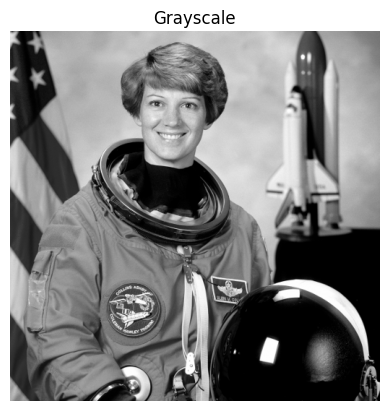

In [15]:
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
print("gray shape:", gray.shape)   # no 3rd dimension -> single channel

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

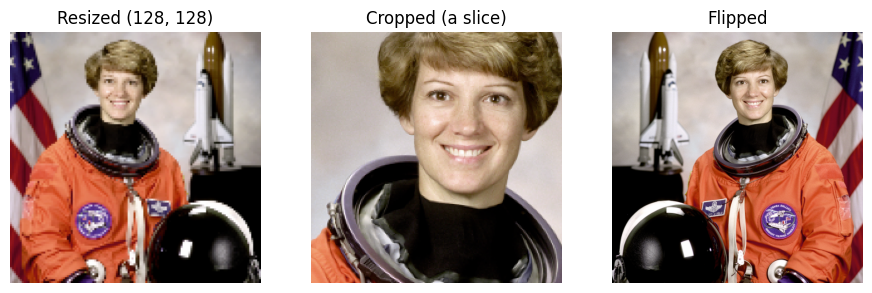

In [18]:
# Resize, crop, and flip — the everyday operations
resized = cv2.resize(img, (128, 128))     # make it smaller (width, height)
cropped = img[50:250, 100:300]            # crop = array slicing! [rows, cols]
flipped = cv2.flip(img, 1)                # 1 = horizontal mirror

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(resized); ax[0].set_title(f"Resized {resized.shape[:2]}"); ax[0].axis("off")
ax[1].imshow(cropped); ax[1].set_title("Cropped (a slice)");            ax[1].axis("off")
ax[2].imshow(flipped); ax[2].set_title("Flipped");                      ax[2].axis("off")
plt.show()

> Notice **cropping is just array slicing** — the same `[start:stop]` you used on lists and strings, now in 2D.

🔵 **Your turn:** resize `img` to 64×64, and crop out just the top-left quarter of the original image. Show both.

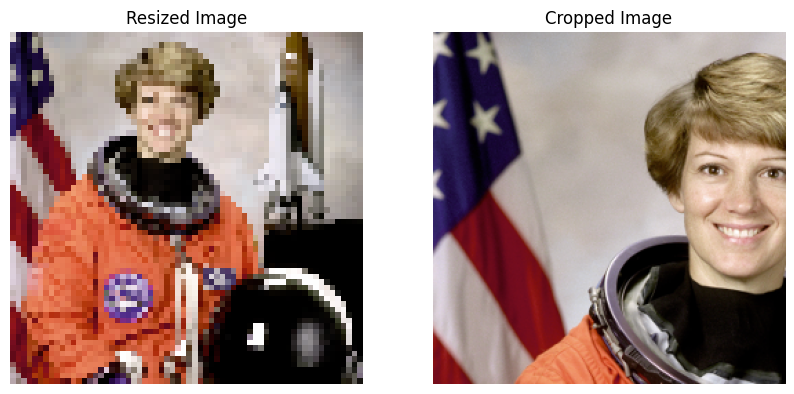

In [20]:
# Write your code here
resized_img = cv2.resize(img, (64, 64))
cropped_img = img[:256, :256]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(resized_img)
plt.title("Resized Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cropped_img)
plt.title("Cropped Image")
plt.axis("off")
plt.show()

In [ ]:
(255,255,3)
(3,255,255)

## 4. Getting an image ready for a model

Models don't eat raw `uint8` images. Two small preparation steps matter:

1. **Normalize** — scale pixel values from `0..255` down to `0.0..1.0`. Networks train better with small numbers.
2. **Channel order** — libraries like PyTorch expect **channels-first**: `(channels, height, width)` instead of `(height, width, channels)`.

Keep this in the back of your mind — wrong preprocessing is the #1 reason a model gives garbage.

In [21]:
# 1) normalize
normalized = img / 255.0
print("before -> min", img.min(), "max", img.max())
print("after  -> min", round(normalized.min(),2), "max", round(normalized.max(),2))


before -> min 0 max 255
after  -> min 0.0 max 1.0


In [22]:
(512,512,3)
# 2) channels-first (H, W, C) -> (C, H, W)
chw = np.transpose(normalized, (2, 0, 1))
print("HWC shape:", normalized.shape, "-> CHW shape:", chw.shape)

HWC shape: (512, 512, 3) -> CHW shape: (3, 512, 512)


## 5. Convolution — the heart of CNNs

A **convolution** slides a tiny grid of numbers (a **kernel** or **filter**) across the image. At each spot it multiplies-and-sums the overlapping pixels, producing one output number. The full output is a **feature map** that highlights whatever pattern the filter is tuned to (edges, blur, etc.).

Don't worry about the math — just *watch what different filters do.*

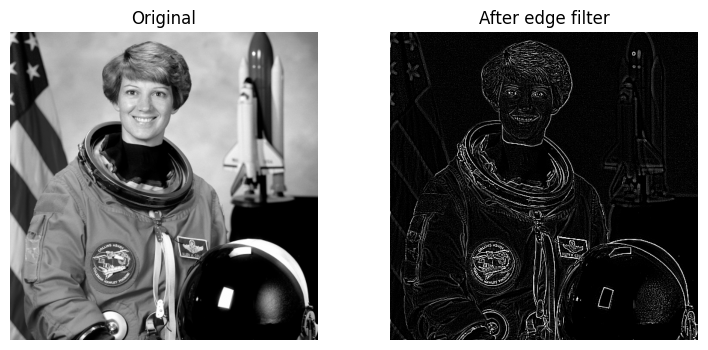

In [23]:
# An "edge detector" kernel: reacts strongly where brightness changes
edge_kernel = np.array([[-1, -1, -1],[-1,  8, -1],[-1, -1, -1]], dtype=np.float32)

edges = cv2.filter2D(gray, -1, edge_kernel)   # apply the filter

plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.imshow(gray,  cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(edges, cmap="gray"); plt.title("After edge filter"); plt.axis("off")
plt.show()

Different kernels = different effects. Same operation, different numbers in the grid.

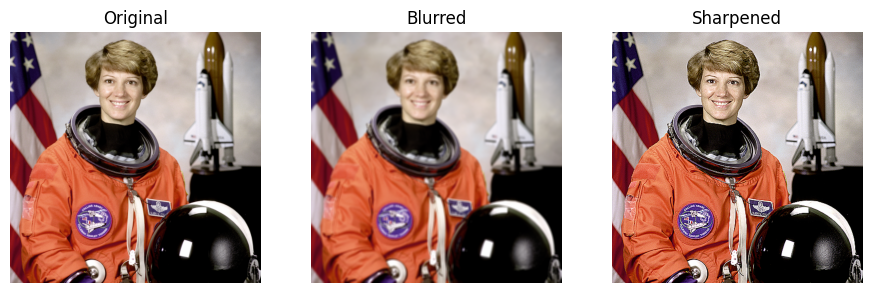

In [27]:
blur_kernel    = np.ones((5,5), np.float32) / 25          # average -> blur
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], np.float32)

blurred   = cv2.filter2D(img, -1, blur_kernel)
sharpened = cv2.filter2D(img, -1, sharpen_kernel)

fig, ax = plt.subplots(1, 3, figsize=(11,4))
ax[0].imshow(img);       ax[0].set_title("Original");  ax[0].axis("off")
ax[1].imshow(blurred);   ax[1].set_title("Blurred");   ax[1].axis("off")
ax[2].imshow(sharpened); ax[2].set_title("Sharpened"); ax[2].axis("off")
plt.show()

> **The big idea:** we *chose* these kernels by hand. A **CNN learns the kernels itself** during training — it figures out which filters are useful for the task. That's the whole trick.

🔵 **Your turn:** apply the `edge_kernel` to the color `img` (not gray). Show the result. Does it still find edges?

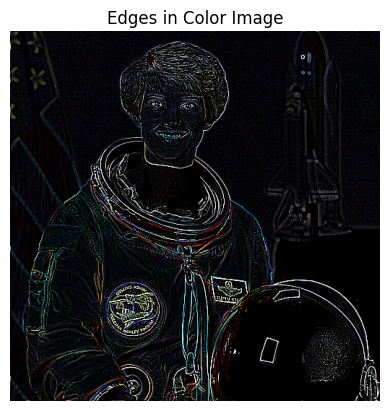

In [32]:
# Write your code here
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)
edges = cv2.filter2D(img, -1, edge_kernel)
plt.imshow(edges)
plt.title("Edges in Color Image")
plt.axis("off")
plt.show()

## 6. Pooling, stride, padding (the three easy extras)

- **Pooling** — shrink a feature map by keeping only the strongest value in each little region (`MaxPool`). Makes the network smaller and more robust.
- **Stride** — how far the filter jumps each step. Bigger stride = smaller output.
- **Padding** — add a border of zeros so the output stays the same size as the input.

You don't compute these by hand — PyTorch does it. Just know the words.

In [34]:
# Max pooling by hand on a tiny example: take the biggest value in each 2x2 block
small = np.array([
    [1, 3, 2, 4,5, 6, 1, 2,7, 8, 3, 0,1, 2, 9, 4]])
pooled = np.array([
    [max(1,3,5,6), max(2,4,1,2)],
    [max(7,8,1,2), max(3,0,9,4)]
])
print("before (4x4):\n", small)
print("after 2x2 max-pool (2x2):\n", pooled)

before (4x4):
 [[1 3 2 4]
 [5 6 1 2]
 [7 8 3 0]
 [1 2 9 4]]
after 2x2 max-pool (2x2):
 [[6 4]
 [8 9]]


In [39]:
512/12

42.666666666666664

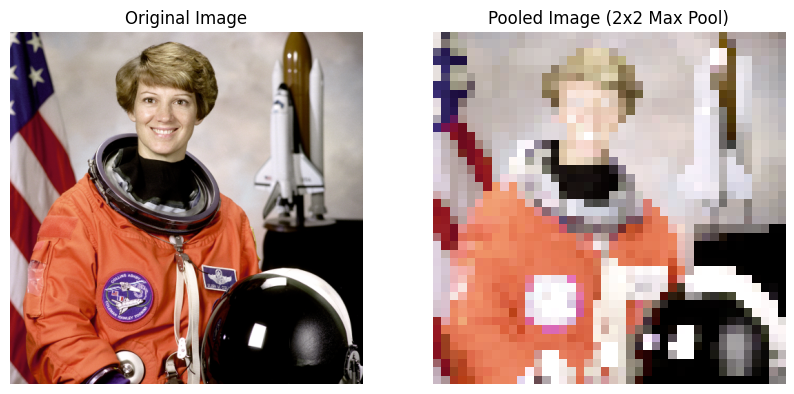

In [38]:
import torch.nn as nn
import torch # Added import for torch

# Convert the image to a PyTorch tensor and move channels to the first dimension
# img is (H, W, C), we need (N, C, H, W) for PyTorch Conv2d/MaxPool2d
img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()

# Define a MaxPool2d layer with a 2x2 kernel
pool_layer = nn.MaxPool2d(kernel_size=12, stride=12);

# Apply max pooling
pooled_tensor = pool_layer(img_tensor)

# Convert the pooled tensor back to a NumPy array for display
# Remove batch dimension, permute back to (H, W, C), and convert to uint8
pooled_img = pooled_tensor.squeeze(0).permute(1, 2, 0).byte().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(pooled_img)
ax[1].set_title("Pooled Image (2x2 Max Pool)")
ax[1].axis("off")
plt.show()

In [40]:
512*512

262144

## 7. Putting it together: a CNN

A typical CNN just **stacks** these pieces:

```
image → [Conv → ReLU → Pool] → [Conv → ReLU → Pool] → Flatten → Dense → prediction
```

- The **conv/pool** blocks extract features (edges → shapes → objects, roughly).
- The final **dense** layers make the decision, exactly like the networks you already know.

**Why not just use a normal (dense) network?** A dense net on a 512×512×3 image would need *hundreds of millions* of weights and would ignore that nearby pixels belong together. CNNs reuse the same small filter everywhere, so they need **far fewer weights** and naturally respect image structure.

Here's what a small CNN looks like in PyTorch — you'll build and train this in the lab.

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 1 channel in, 8 filters
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 8 -> 16 filters
        self.pool  = nn.MaxPool2d(2, 2)                          # halve the size
        self.fc1   = nn.Linear(16 * 7 * 7, 64)                   # dense layers
        self.fc2   = nn.Linear(64, 10)                          # 10 classes (digits)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # conv -> relu -> pool
        x = self.pool(F.relu(self.conv2(x)))   # again
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN()
print(model)
print("total weights:", sum(p.numel() for p in model.parameters()))

SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
total weights: 52138


> That's only ~50k weights — tiny, and it will still read handwritten digits well. Notice it's the same OOP you learned: a class, `__init__`, `self`, methods. CNNs are just classes.

## ✅ Recap

- An **image is a NumPy array**: grayscale `(H, W)`, color `(H, W, 3)`; pixels are `0..255`.
- **OpenCV** loads (as BGR!), converts, resizes, crops, flips.
- Models want images **normalized** and **channels-first**.
- **Convolution** slides a **filter** over an image to make a **feature map**; different filters find different patterns.
- A **CNN** stacks conv + pool blocks then dense layers, and **learns its own filters** — with far fewer weights than a dense net.

**Next (Lab):** manipulate images, apply filters and see feature maps, then build and train this CNN on real handwritten digits. Open `CV_Session1_Lab.ipynb`.

**Session 2 preview:** instead of training from scratch, we'll grab **pretrained models** that already know how to see — and adapt them to new tasks in minutes.